# Inferência - YOLOv11

Notebook dedicado exclusivamente à inferência do modelo treinado em imagens de teste e em imagens externas.

In [6]:
import importlib.util
import subprocess
import sys

required_packages = ["ultralytics", "torch", "matplotlib", "Pillow", "numpy", "pandas"]
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg.replace("Pillow", "PIL")) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("Dependências instaladas:", ", ".join(missing))
else:
    print("Dependências já instaladas.")

Dependências já instaladas.


In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from IPython.display import display

In [8]:
import torch

PROJECT_ROOT = Path.cwd()
BASE_DIR = PROJECT_ROOT / "pcb-defect-subset-5000"
RUNS_ROOT = PROJECT_ROOT / "runs" / "detect"

RUNS_DIR = RUNS_ROOT / "tcc_pcb_defect_detection" / "yolo11"

EVAL_OUT_DIR = RUNS_ROOT / "eval_results"
EVAL_OUT_DIR.mkdir(parents=True, exist_ok=True)

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = 0
else:
    DEVICE = "cpu"

EVAL_DEVICE = "cpu" if DEVICE == "mps" else DEVICE

if not BASE_DIR.exists():
    raise FileNotFoundError(f"Dataset não encontrado: {BASE_DIR}")

candidate_weights = sorted(RUNS_DIR.rglob("best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
if not candidate_weights:
    raise FileNotFoundError("Nenhum arquivo best.pt foi encontrado nos diretorios de experimentos")

MODEL_PATH = candidate_weights[0]
TEST_IMAGES_DIR = BASE_DIR / "test" / "images"

print(f"Device detectado: {DEVICE}")
print(f"Device em uso para avaliacao: {EVAL_DEVICE}")
print(f"Modelo selecionado: {MODEL_PATH}")
print(f"Imagens de teste: {TEST_IMAGES_DIR}")
print(f"Saidas de avaliacao: {EVAL_OUT_DIR}")

Device detectado: mps
Device em uso para avaliacao: cpu
Modelo selecionado: /Users/alehholiveira/Desktop/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/yolo11/20260405_1422_yolo11n_img640_e50_bs16_seed42_baseline/weights/best.pt
Imagens de teste: /Users/alehholiveira/Desktop/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/pcb-defect-subset-5000/test/images
Saidas de avaliacao: /Users/alehholiveira/Desktop/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/eval_results


In [9]:
def infer_and_plot(image_paths, conf=0.25):
    image_paths = [Path(p) for p in image_paths]
    outputs = []

    predict_model = YOLO(str(MODEL_PATH))

    for image_path in image_paths:
        if not image_path.exists():
            print(f"Arquivo não encontrado: {image_path}")
            continue

        results = predict_model.predict(str(image_path), conf=conf, device=EVAL_DEVICE, verbose=False)
        for result in results:
            im_array = result.plot()
            im = Image.fromarray(im_array[..., ::-1])
            out_file = EVAL_OUT_DIR / f"pred_{image_path.stem}.png"
            im.save(out_file)

            plt.figure(figsize=(10, 10))
            plt.imshow(im)
            plt.axis("off")
            plt.title(f"{image_path.name} | detecções: {len(result.boxes)}")

            outputs.append({
                "image": str(image_path),
                "output": str(out_file),
                "detections": int(len(result.boxes)),
            })

    return outputs

,image,output,detections
0,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,2
1,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,1
2,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,2
3,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,1


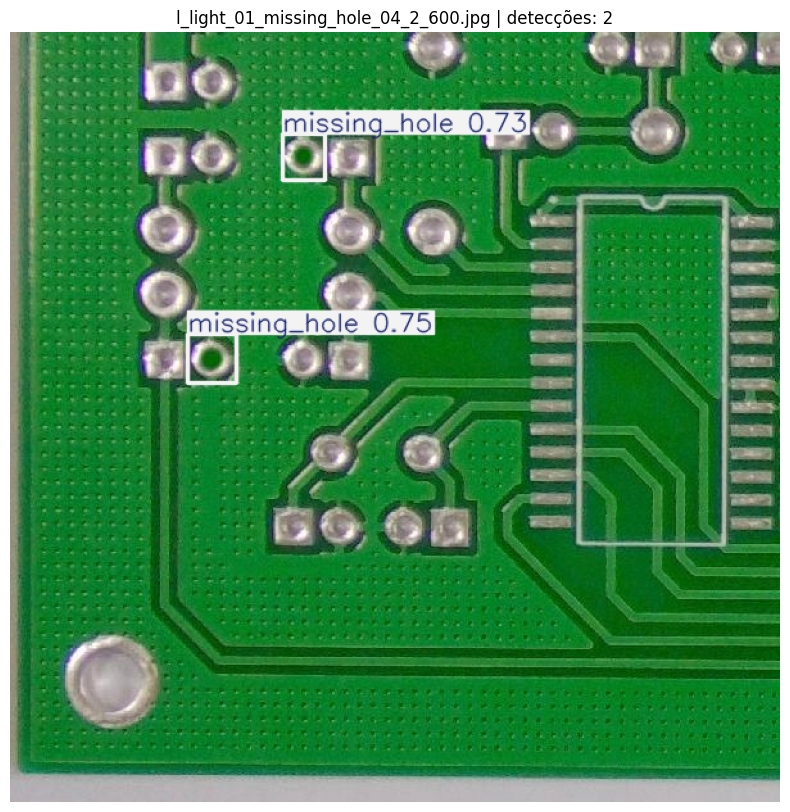

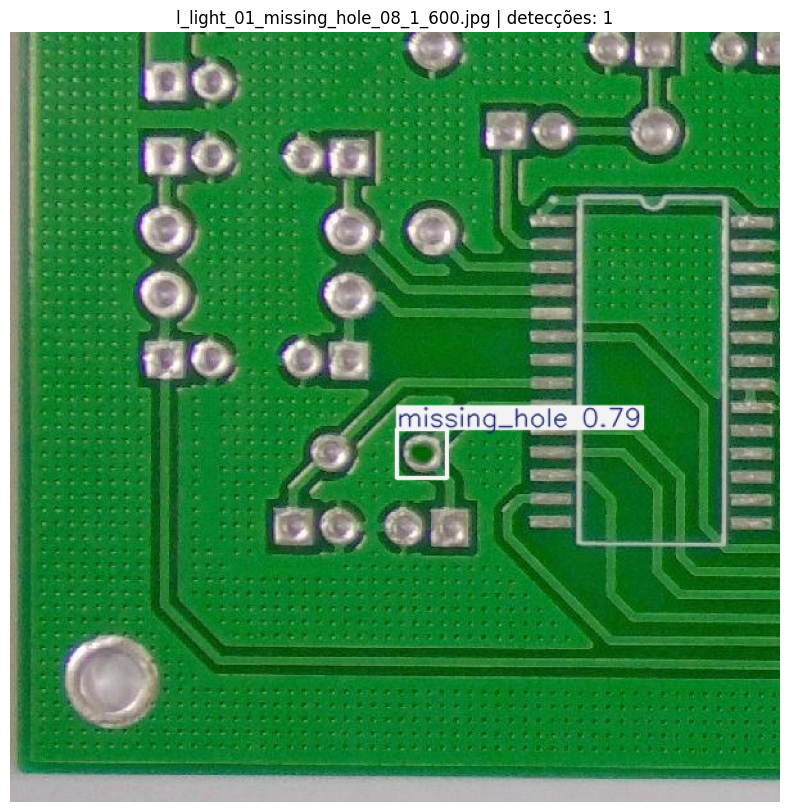

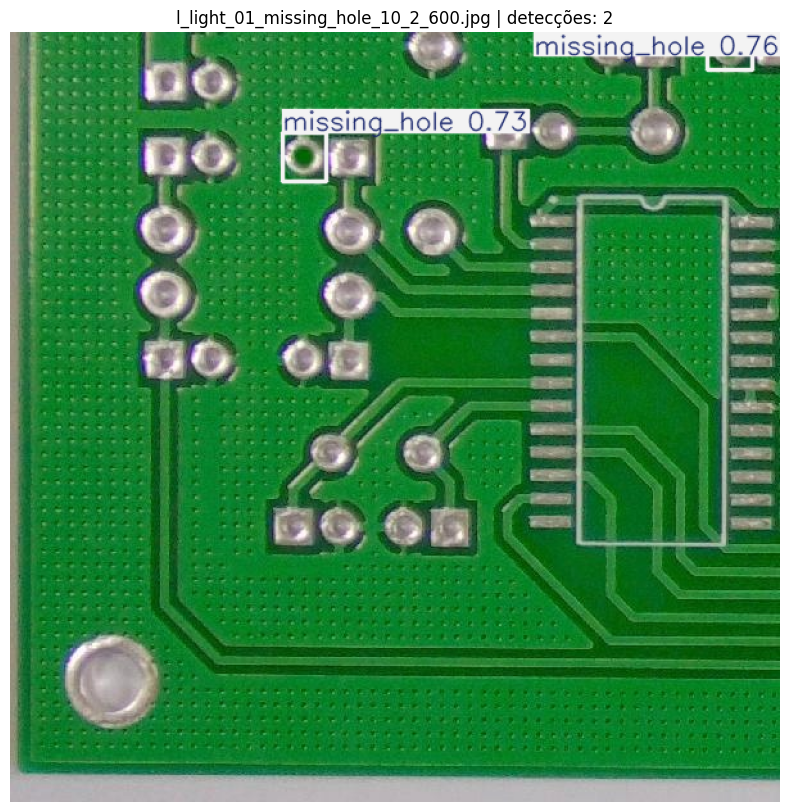

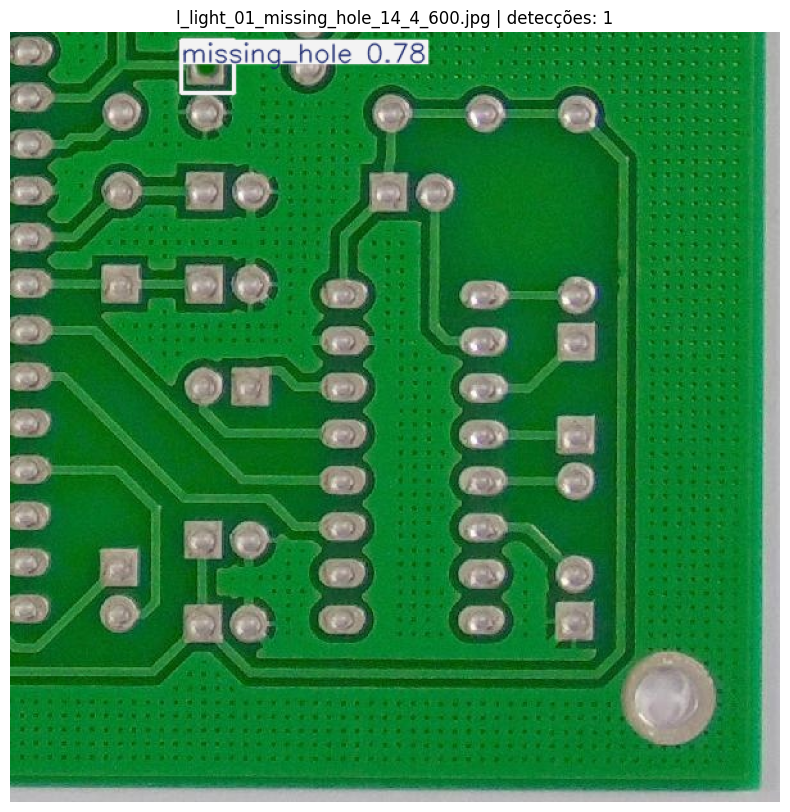

In [10]:
test_candidates = []
for pattern in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    test_candidates.extend(sorted(TEST_IMAGES_DIR.glob(pattern)))

# Remove duplicatas mantendo ordem
seen = set()
unique_candidates = []
for p in test_candidates:
    if p not in seen:
        unique_candidates.append(p)
        seen.add(p)

test_candidates = unique_candidates[:4]

if not test_candidates:
    raise FileNotFoundError(f"Nenhuma imagem de teste encontrada em: {TEST_IMAGES_DIR}")

infer_results = infer_and_plot(test_candidates, conf=0.25)
results_df = pd.DataFrame(infer_results)
results_df